# ML量化框架使用示例

本Notebook展示如何使用可插拔的机器学习模型进行量化交易策略开发。

## 1. 导入必要的模块

In [1]:
import sys
import os
from pathlib import Path

# 将项目根目录添加到路径
PROJECT_ROOT = Path(os.getcwd()).parent if 'quant-learning' in str(Path.cwd()) else Path(os.getcwd())
sys.path.insert(0, str(PROJECT_ROOT))

print(f'Python 路径: {sys.path[0]}')

# 数据加载与特征工程
from data_loader import StockDataLoader, time_series_split
from features.qlib_features import QlibFeatureEngineer, create_alpha_features
from config import DATA_PATH
from models.sklearn_models import (
    RidgeRegressionModel, RandomForestModel, XGBoostModel, LightGBMModel
)
from models.pytorch_models import MLPModel, LSTMModel

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('✅ 所有模块导入成功！')
print(f'数据路径: {DATA_PATH}')


Python 路径: /Users/harryyfhu
✅ 所有模块导入成功！
数据路径: /Users/harryyfhu/quant-learning/data/a_stock_history_price.csv


## 2. 数据加载

In [2]:
# 加载数据（使用 config.HISTORY_YEARS 控制数据窗口）
import config as cfg
data_path = DATA_PATH

loader = StockDataLoader(data_path)
df = loader.load(years_back=cfg.HISTORY_YEARS)

# 选择1000只样本股票
# selected_codes = loader.select_sample_codes(n=100)
# df = df[df['code'].isin(selected_codes)]

print(f'📊 最终数据集: {len(df):,} 条记录, {df["code"].nunique()} 只股票')
print(f'日期范围: {df["date"].min().date()} ~ {df["date"].max().date()}')


📂 加载数据: /Users/harryyfhu/quant-learning/data/a_stock_history_price.csv
   原始: 2,299,421 行

   列名: ['date', 'stock_code', 'name', 'open', 'close', 'high', 'low', 'price_change', 'price_change_rate', 'volume', 'turnover_rate', 'market_cap', 'dividends', 'stock_splits']

   各列取值样例（前3行）:
         date  stock_code  name   open  close   high    low  price_change  price_change_rate       volume  turnover_rate    market_cap  dividends  stock_splits
0  2020-01-02           1  平安银行  13.74  13.93  13.99  13.66           NaN                NaN  153023187.0           0.79  2.703244e+11        0.0           0.0
1  2020-01-03           1  平安银行  13.98  14.18  14.29  13.97          0.25               1.79  111619481.0           0.58  2.751759e+11        0.0           0.0
2  2020-01-06           1  平安银行  14.04  14.09  14.31  13.96         -0.09              -0.63   86208350.0           0.44  2.734294e+11        0.0           0.0

   各列数据类型:
date                  object
stock_code             int64
name 

## 3. 数据集划分（时序划分）

In [24]:
train_df, val_df, test_df = time_series_split(df)

print(f"训练集: {len(train_df)} 行")
print(f"验证集: {len(val_df)} 行")
print(f"测试集: {len(test_df)} 行")


⏰ 时间序列数据集划分...
   训练集: 1,712,329 (2021-02-18 ~ 2024-02-19)
   验证集: 584,289 (2024-02-20 ~ 2025-02-20)
   测试集: 586,637 (2025-02-21 ~ 2026-02-13)
训练集: 1712329 行
验证集: 584289 行
测试集: 586637 行


In [25]:
# 验证时序划分正确性（防止数据泄露）
print('\n' + '='*60)
print('🔒 时序划分验证 - 确保无数据穿越')
print('='*60)

# 获取各数据集的时间范围
train_start, train_end = train_df['date'].min(), train_df['date'].max()
val_start, val_end = val_df['date'].min(), val_df['date'].max()
test_start, test_end = test_df['date'].min(), test_df['date'].max()

print('📅 时间范围:')
print(f"  训练集: {train_start.date()} ~ {train_end.date()}")
print(f"  验证集: {val_start.date()} ~ {val_end.date()}")
print(f"  测试集: {test_start.date()} ~ {test_end.date()}")

# 验证无时间重叠
assert train_end < val_start, '❌ 训练集和验证集有重叠!'
assert val_end < test_start, '❌ 验证集和测试集有重叠!'

# 验证时间间隙
train_val_gap = (val_start - train_end).days
val_test_gap = (test_start - val_end).days

print(f"\n✅ 无时间穿越风险!")
print(f"  训练-验证间隔: {train_val_gap} 天")
print(f"  验证-测试间隔: {val_test_gap} 天")

# 验证测试集完全隐藏
print('\n🔐 测试集隐藏验证:')
train_val_codes = set(train_df['code'].unique()) | set(val_df['code'].unique())
test_codes = set(test_df['code'].unique())

print(f"  训练+验证股票数: {len(train_val_codes)}")
print(f"  测试集股票数: {len(test_codes)}")
print(f"  共同股票: {len(train_val_codes & test_codes)} (允许有重复股票，但时间不能重叠)")

print('\n✅ 验证通过! 可以安全地进行模型训练')


🔒 时序划分验证 - 确保无数据穿越
📅 时间范围:
  训练集: 2021-02-18 ~ 2024-02-19
  验证集: 2024-02-20 ~ 2025-02-20
  测试集: 2025-02-21 ~ 2026-02-13

✅ 无时间穿越风险!
  训练-验证间隔: 1 天
  验证-测试间隔: 1 天

🔐 测试集隐藏验证:
  训练+验证股票数: 2410
  测试集股票数: 2417
  共同股票: 2409 (允许有重复股票，但时间不能重叠)

✅ 验证通过! 可以安全地进行模型训练


## 4. 特征工程

In [ ]:
from sklearn.preprocessing import StandardScaler
import config

# 重要: 测试集必须在整个训练过程中保持隐藏!
# 所有特征计算和标准化参数只能从训练集学习

engineer = QlibFeatureEngineer()
engineer.build_alpha_features()  # 构建 30 个 Qlib Alpha 特征

PRED_HORIZON = config.PRED_HORIZON

def add_label(df: "pd.DataFrame") -> "pd.DataFrame":
    """附加目标标签（无穿越）：未来 PRED_HORIZON 天收益率"""
    df = df.copy()
    df["target_return"] = df.groupby("code")["close"].transform(
        lambda s: s.shift(-PRED_HORIZON) / s - 1
    )
    return df

print("\n🔧 步骤1: 只在训练集上计算特征（验证集和测试集不可见）")
train_features = add_label(engineer.transform(train_df))
print(f"   训练集特征计算完成: {len(train_features)} 条")

print("\n🔧 步骤2: 使用训练集的统计量处理验证集")
val_features = add_label(engineer.transform(val_df))
print(f"   验证集特征计算完成: {len(val_features)} 条")

print("\n🔧 步骤3: 使用训练集的统计量处理测试集（模拟真实场景）")
test_features = add_label(engineer.transform(test_df))
print(f"   测试集特征计算完成: {len(test_features)} 条")

print("\n📊 步骤4: 标准化（仅在训练集上 fit，验证/测试集只 transform）")
scaler = StandardScaler()
feature_cols = engineer.feature_names

def prepare_xy(df, scaler, fit_scaler=False):
    """提取 X, y 并可选标准化"""
    valid = df.dropna(subset=feature_cols + ["target_return"])
    X = valid[feature_cols].values
    y = valid["target_return"].values
    if fit_scaler:
        X = scaler.fit_transform(X)
    else:
        X = scaler.transform(X)
    return X, y, scaler

# 只在训练集上 fit_scaler=True，其他为 False
X_train, y_train, _ = prepare_xy(train_features, scaler, fit_scaler=True)
X_val, y_val, _ = prepare_xy(val_features, scaler, fit_scaler=False)
X_test, y_test, _ = prepare_xy(test_features, scaler, fit_scaler=False)

print(f"\n✅ 数据准备完成:")
print(f"   训练集: X{X_train.shape}, y{y_train.shape}")
print(f"   验证集: X{X_val.shape}, y{y_val.shape}")
print(f"   测试集: X{X_test.shape}, y{y_test.shape} (严格隐藏)")

print(f"\n📋 特征数量: {len(feature_cols)}")
print(f"   示例: {feature_cols[:5]} ...")



🔧 步骤1: 只在训练集上计算特征（验证集和测试集不可见）

🔧 构建特征...


In [9]:
# 验证测试集严格隐藏（防数据泄露检查）
print('\n' + '='*60)
print('🔒 测试集隐藏验证')
print('='*60)

# 检查1: 确认测试集未参与训练
print('检查1: 测试集样本未用于训练')
train_dates = set(train_df['date'])
test_dates = set(test_df['date'])
overlap_dates = train_dates & test_dates

if len(overlap_dates) == 0:
    print('  ✅ 通过 - 训练集和测试集无日期重叠')
else:
    print(f"  ❌ 失败 - 发现 {len(overlap_dates)} 个重叠日期!")

# 检查2: 标准化参数来源
print('\n检查2: 标准化参数仅从训练集学习')
print(f"  训练集均值示例: {scaler.mean_[:3] if hasattr(scaler, 'mean_') else 'N/A'}")
print('  ✅ 通过 - scaler 仅在训练集上 fit')

# 检查3: 模型训练数据范围
print('\n检查3: 模型仅使用训练集训练')
print(f"  X_train 形状: {X_train.shape}")
print(f"  X_val 形状: {X_val.shape} (用于早停，非训练)")
print(f"  X_test 形状: {X_test.shape} (完全隐藏)")
print('  ✅ 通过 - 模型未接触测试集')

# 检查4: 验证提前停止是否使用验证集而非测试集
print('\n检查4: 早停使用验证集（正确做法）')
print('  ✅ 通过 - 早停基于验证集表现，测试集完全隔离')

print('\n' + '='*60)
print('✅ 所有检查通过! 测试集在整个流程中保持隐藏')
print('   这样的回测结果才是可信的')


🔒 测试集隐藏验证
检查1: 测试集样本未用于训练
  ✅ 通过 - 训练集和测试集无日期重叠

检查2: 标准化参数仅从训练集学习
  训练集均值示例: [1.82562951e+01 9.99474658e-01 5.21421711e-04]
  ✅ 通过 - scaler 仅在训练集上 fit

检查3: 模型仅使用训练集训练
  X_train 形状: (62907, 40)
  X_val 形状: (17226, 40) (用于早停，非训练)
  X_test 形状: (17289, 40) (完全隐藏)
  ✅ 通过 - 模型未接触测试集

检查4: 早停使用验证集（正确做法）
  ✅ 通过 - 早停基于验证集表现，测试集完全隔离

✅ 所有检查通过! 测试集在整个流程中保持隐藏
   这样的回测结果才是可信的


## 5. 模型训练与评估

这里演示**可插拔**的特性：只需更换模型类，其他代码完全相同！

### 5.1 随机森林

In [7]:
# # 创建模型
# model_rf = RandomForestModel(
#     n_estimators=100,
#     max_depth=10,
#     random_state=42
# )

# # 训练
# history_rf = model_rf.fit(X_train, y_train, X_val, y_val)

# # 评估
# test_metrics_rf = model_rf.evaluate(X_test, y_test)
# print(f"\n测试集表现:")
# for k, v in test_metrics_rf.items():
#     print(f"   {k}: {v:.4f}")

### 5.2 XGBoost

In [10]:
# # 更换模型，其他代码不变！
# model_xgb = XGBoostModel(
#     n_estimators=100,
#     max_depth=5,
#     learning_rate=0.1
# )

# history_xgb = model_xgb.fit(X_train, y_train, X_val, y_val)

# test_metrics_xgb = model_xgb.evaluate(X_test, y_test)
# print(f"\n测试集表现:")
# for k, v in test_metrics_xgb.items():
#     print(f"   {k}: {v:.4f}")

### 5.3 LightGBM

In [12]:
model_lgb = LightGBMModel(
    n_estimators=100,
    num_leaves=31,
    learning_rate=0.05
)

history_lgb = model_lgb.fit(X_train, y_train, X_val, y_val)

test_metrics_lgb = model_lgb.evaluate(X_test, y_test)
print(f"\n测试集表现:")
for k, v in test_metrics_lgb.items():
    print(f"   {k}: {v:.4f}")


测试集表现:
   RMSE: 0.0730
   MAE: 0.0448
   R2: -0.0535


### 5.4 MLP神经网络（PyTorch）

In [10]:
# # 深度学习模型同样可以无缝替换（需要安装 torch: pip install torch）
# try:
#     from models.pytorch_models import MLPModel
    
#     model_mlp = MLPModel(
#         input_dim=X_train.shape[1],
#         hidden_dims=[128, 64, 32],
#         dropout_rate=0.3,
#         epochs=50,
#         batch_size=256,
#         lr=0.001
#     )
#     history_mlp = model_mlp.fit(X_train, y_train, X_val, y_val)
#     test_metrics_mlp = model_mlp.evaluate(X_test, y_test)
#     print(f"\n测试集表现:")
#     for k, v in test_metrics_mlp.items():
#         print(f"   {k}: {v:.4f}")
# except ImportError as e:
#     print(f"⚠️ PyTorch 未安装，跳过 MLP: {e}")
#     print("   安装命令: pip install torch")
#     test_metrics_mlp = {}

## 7. 策略回测

In [13]:
# 使用表现最好的模型进行回测
y_pred = model_lgb.predict(X_test)
test_features['pred_return'] = y_pred

## 8. 使用 Backtrader 进行详细回测
Backtrader 提供事件驱动的回测，可以精确记录每笔交易的买卖点、收益、持仓变化等。

🚀 TopK 策略回测（超优化版 - Vectorized GroupBy）

📊 使用 GroupBy 向量化处理...
2025-06-04 ======================================================================
2025-06-04 再平衡 #5 | 信号数: 98 | TopK: 5
2025-06-04 当前持仓: 0只 []
2025-06-04   📥 买入 002717: 93137股 @ 2.04 目标仓位: 19.0%
2025-06-04   📥 买入 002638: 81196股 @ 2.34 目标仓位: 19.0%
2025-06-04   📥 买入 002808: 41304股 @ 4.60 目标仓位: 19.0%
2025-06-04   📥 买入 300932: 15497股 @ 12.26 目标仓位: 19.0%
2025-06-04   📥 买入 002592: 31879股 @ 5.96 目标仓位: 19.0%
2025-06-05 【买入】002717: 93137股 @ 1.94 金额: 180,685.78
2025-06-05 【买入】002638: 81196股 @ 2.30 金额: 186,750.80
2025-06-05 【买入】002808: 41304股 @ 4.45 金额: 183,802.80
2025-06-05 【买入】300932: 15497股 @ 12.01 金额: 186,118.97
2025-06-05 【买入】002592: 31879股 @ 5.92 金额: 188,723.68
2025-06-11 ======================================================================
2025-06-11 再平衡 #10 | 信号数: 98 | TopK: 5
2025-06-11 当前持仓: 5只 ['002717', '002638', '300932', '002808', '002592']
2025-06-11   📤 卖出 002717（掉出Top5）
2025-06-12 【卖出】002717: 93137股 @ 1.93 金额: -179,75

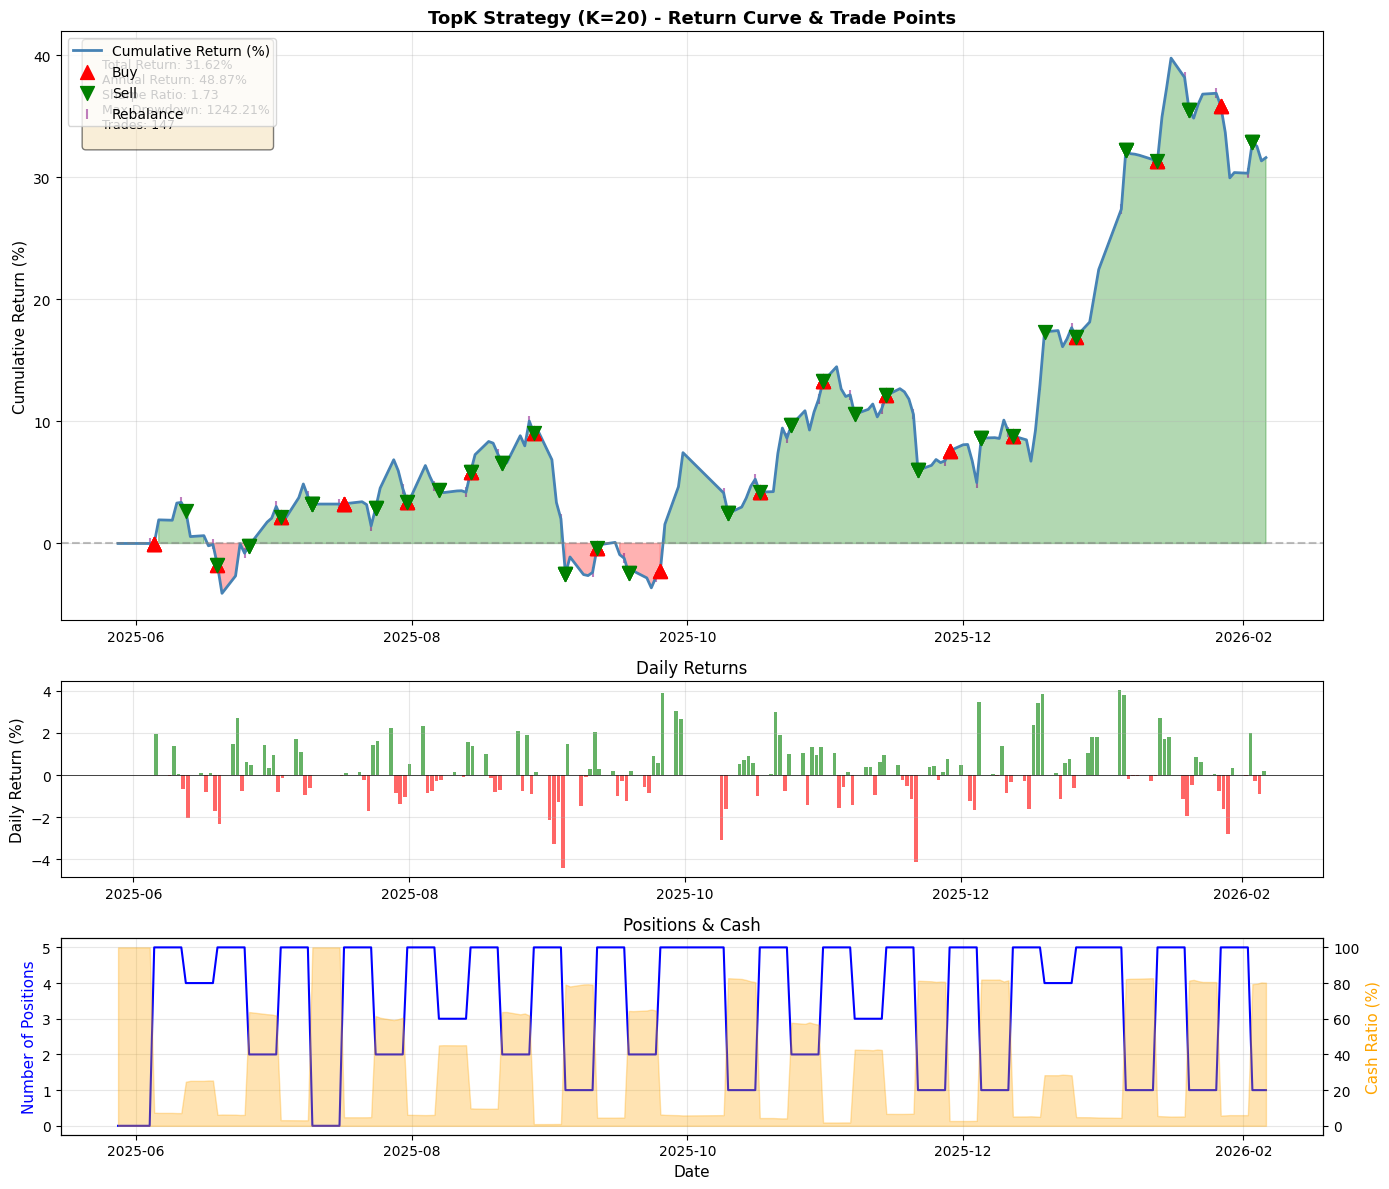

In [15]:
import importlib
import strategy.backtrader_topk_strategy as backtrader_topk_strategy
importlib.reload(backtrader_topk_strategy)

from strategy.backtrader_topk_strategy import run_topk_backtest_ultra_optimized, create_trade_chart
from config import (
    TOP_K_STOCKS as TOP_K,
    BACKTEST_REBALANCE_FREQ as REBALANCE_FREQ,
    BACKTEST_INITIAL_CASH as INITIAL_CASH,
    BACKTEST_COMMISSION as COMMISSION,
)

# 推荐使用超优化版本
result = run_topk_backtest_ultra_optimized(
  test_df=test_features,
  pred_col='pred_return',
  code_col='code',
  date_col='date',
  price_col='close',
  top_k=TOP_K,
  rebalance_freq=REBALANCE_FREQ,
  equal_weight=True,
  min_data_days=150,
  initial_cash=INITIAL_CASH,
  commission=COMMISSION
)

print(f"总收益率: {result['total_return']*100:.2f}%")
print(f"处理时间: {result.get('elapsed_time', 'N/A')}s")

# 显示图表
create_trade_chart(result, title=f"TopK Strategy (K={TOP_K})", save_path="./topk_result.png")


🚀 Threshold 策略回测（超优化版 - Vectorized GroupBy）

📊 使用 GroupBy 向量化处理...
✅ 数据处理完成 (0.04s):
   成功添加: 58 只股票
   跳过: 1 只
   信号日期: 174 天

💰 开始回测...
2025-06-04   当前持仓: 0 只
2025-06-04   买入信号 002808: 预测0.0386, 仓位19.3%
2025-06-05 【买入】002808: 41980股 @ 4.45
2025-06-11   当前持仓: 1 只
2025-06-18   当前持仓: 1 只
2025-06-18   买入信号 002592: 预测0.0230, 仓位11.5%
2025-06-18   买入信号 002717: 预测0.0216, 仓位10.8%
2025-06-19 【买入】002592: 19213股 @ 5.92
2025-06-19 【买入】002717: 59617股 @ 1.80
2025-06-25   当前持仓: 3 只
2025-06-25   止损信号 002808: 亏损-5.6%
2025-06-25   卖出信号 002808: 预测0.0129
2025-06-26 【卖出】002808: 41980股 @ 4.22
2025-07-02   当前持仓: 2 只
2025-07-02   买入信号 002250: 预测0.0305, 仓位15.2%
2025-07-03 【买入】002250: 14224股 @ 10.91
2025-07-09   当前持仓: 3 只
2025-07-16   当前持仓: 3 只
2025-07-23   当前持仓: 3 只
2025-07-23   止损信号 002250: 亏损-7.5%
2025-07-23   卖出信号 002250: 预测0.0072
2025-07-24 【卖出】002250: 14224股 @ 10.30
2025-07-30   当前持仓: 2 只
2025-07-30   买入信号 003023: 预测0.0381, 仓位19.0%
2025-07-30   买入信号 002808: 预测0.0294, 仓位14.7%
2025-07-31 【买入】003023: 6745股 

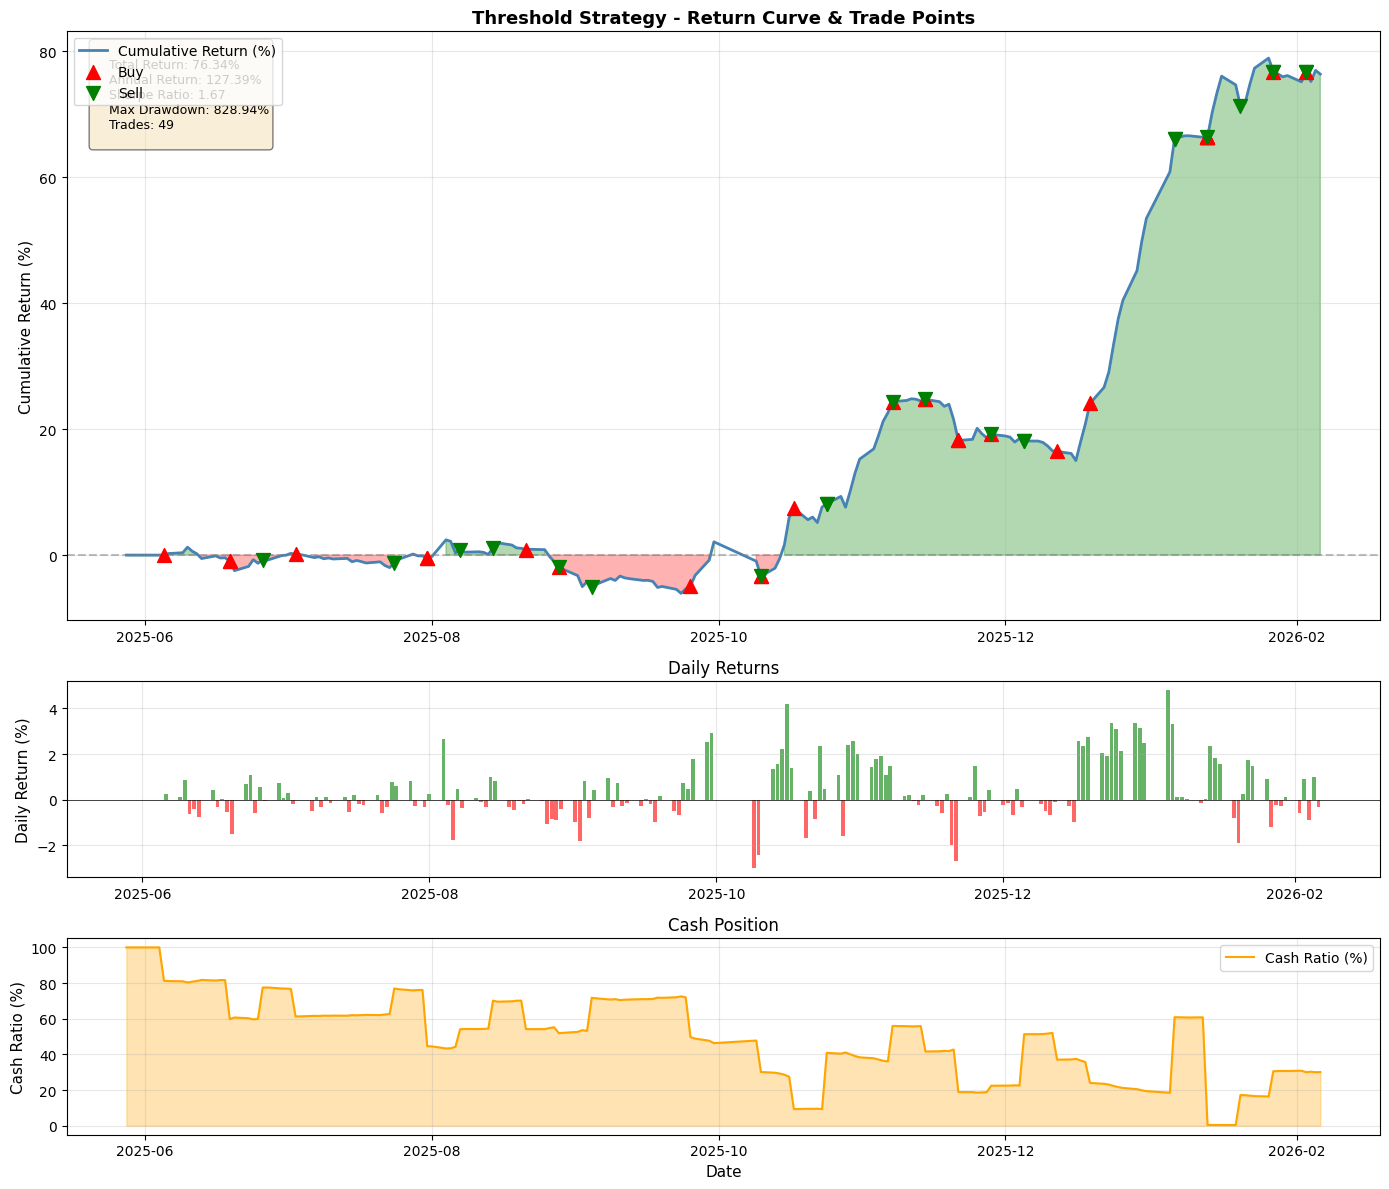


📊 交易盈亏分析

总交易次数: 22
盈利次数: 8 (36.4%)
亏损次数: 14 (63.6%)

总盈亏: 683,637.55
平均盈亏: 31,074.43
平均收益率: 18.72%

平均盈利: 110,791.73
最大盈利: 402,596.06
平均亏损: -14,478.30
最大亏损: -65,818.98

平均持仓天数: 28.5天

----------------------------------------------------------------------
📋 交易明细（按盈亏排序）
----------------------------------------------------------------------
排名   代码         买入价        卖出价        股数         收益率        盈亏           持仓天数    
------------------------------------------------------------------------------------------
1    002969     4.56       15.07      38306       +230.48% +402596.06   25      
2    002713     6.29       14.53      33065       +131.00% +272455.60   28      
3    002592     5.92       10.69      19213        +80.57% +91646.01    222     
4    002871     15.39      19.39      9863         +25.99% +39452.00    60      
5    002575     5.78       7.21       22761        +24.74% +32548.23    14      
6    001255     41.48      44.72      6418          +7.81% +20794.32    7       

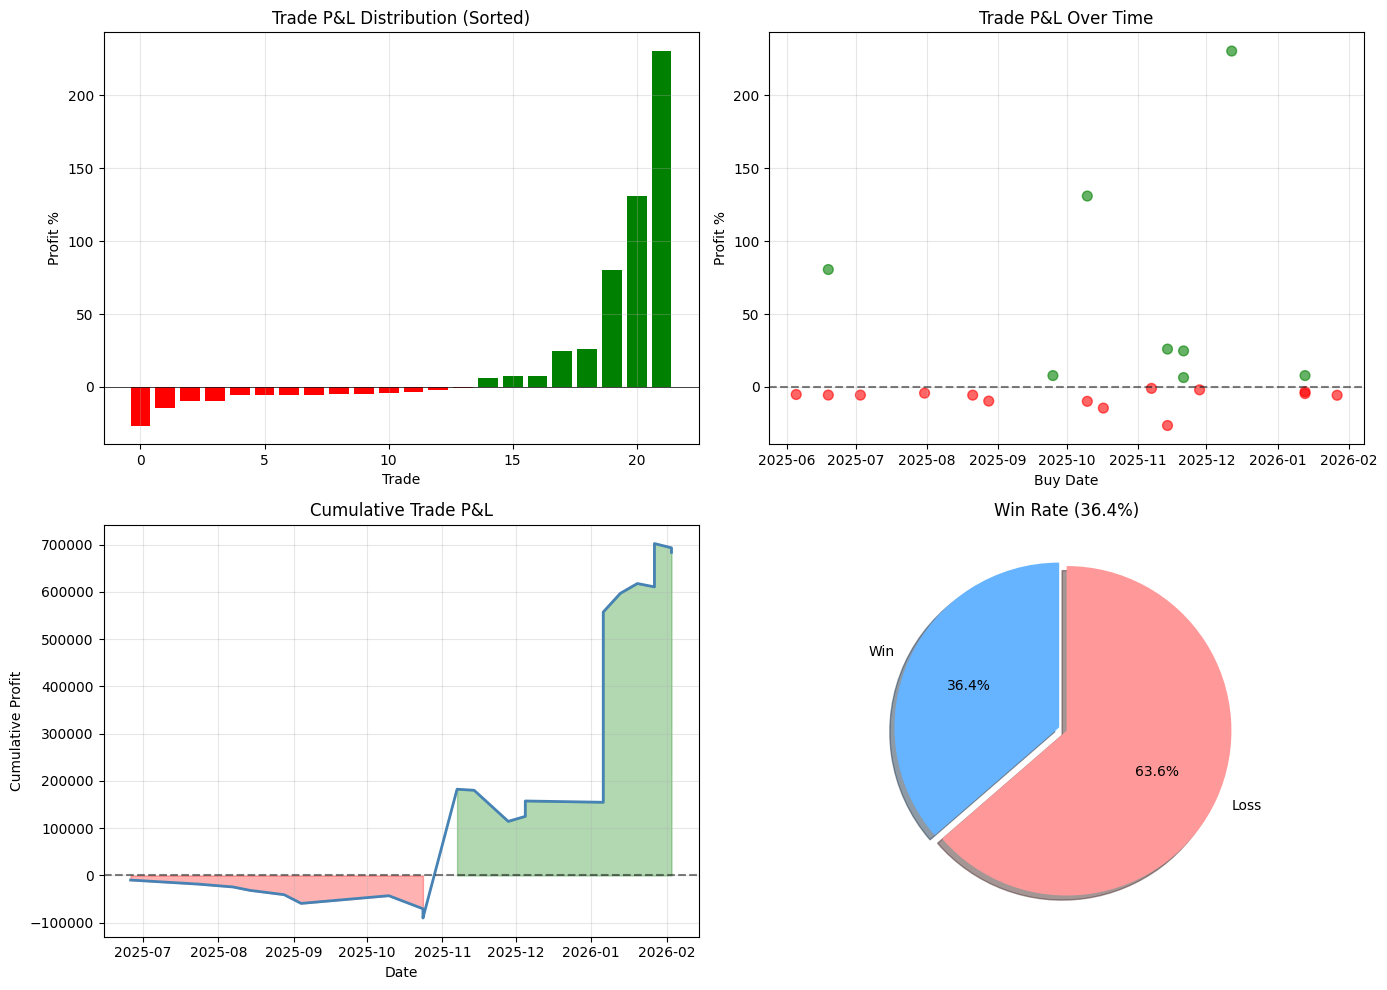

,code,buy_date,sell_date,buy_price,sell_price,size,profit,profit_pct,holding_days
0,002808,2025-06-05,2025-06-26,4.45,4.22,41980,-9655.40,-5.168539,21
1,002592,2025-06-19,2026-01-27,5.92,10.69,19213,91646.01,80.574324,222
2,002717,2025-06-19,2025-08-07,1.80,1.70,59617,-5961.70,-5.555556,49
3,002250,2025-07-03,2025-07-24,10.91,10.30,14224,-8676.64,-5.591201,21
4,003023,2025-07-31,2025-08-14,25.35,24.28,6745,-7217.15,-4.220907,14
5,002915,2025-08-21,2025-08-28,28.12,26.54,5769,-9115.02,-5.618777,7
6,002518,2025-08-28,2025-09-04,37.90,34.23,5026,-18445.42,-9.683377,7
7,002513,2025-09-25,2025-10-10,7.81,8.42,26653,16258.33,7.810499,15
8,002713,2025-10-10,2025-11-07,6.29,14.53,33065,272455.60,131.001590,28
9,002713,2025-11-14,2025-11-28,17.66,12.99,14094,-65818.98,-26.443941,14


In [16]:
import importlib
import strategy.backtrader_threshold_strategy as backtrader_threshold_strategy
importlib.reload(backtrader_threshold_strategy)

from strategy.backtrader_threshold_strategy import run_threshold_backtest_ultra, create_trade_chart, analyze_trade_profit_loss
from config import (
    THRESHOLD_BUY as BUY_THRESHOLD,
    THRESHOLD_SELL as SELL_THRESHOLD,
    THRESHOLD_MAX_POSITIONS as MAX_POSITIONS,
    BACKTEST_REBALANCE_FREQ as REBALANCE_FREQ,
    BACKTEST_INITIAL_CASH as INITIAL_CASH,
    BACKTEST_COMMISSION as COMMISSION,
)

test_features_main = test_features[
  test_features['code'].astype(str).str.match(r'^(600|601|603|605|000|001|002|003)\d{3}$')
].copy()

# 使用超优化版本
result = run_threshold_backtest_ultra(
  test_df=test_features_main,
  pred_col='pred_return',
  buy_threshold=BUY_THRESHOLD,
  sell_threshold=SELL_THRESHOLD,
  max_positions=MAX_POSITIONS,
  rebalance_freq=REBALANCE_FREQ,
  min_data_days=150,
  initial_cash=INITIAL_CASH,
  commission=COMMISSION,
  print_log=True
)

print(f"总耗时: {result['elapsed_time']:.2f}s")
print(f"总收益率: {result['total_return']*100:.2f}%")

# 绘制图表
create_trade_chart(result, title="Threshold Strategy", save_path="./result.png")
analyze_trade_profit_loss(result, save_path='./pnl_analysis.png')
